# VisionICeIO — Real Data Exploration

Interactive notebook for loading and exploring a **real** experiment
directory.  Set your local path and experiment name below, then run
through the cells to:

1. Load the experiment into an `xr.Dataset`
2. Inspect the dataset structure (variables, dimensions, metadata)
3. Visualise waveforms, spike rasters, and LFP traces
4. Load or import spike-sorting results
5. Optionally persist to / reload from Zarr

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import PCG64DXSM, Generator, SeedSequence

import visioniceio
from visioniceio import Experiment, load_from_zarr

print(f"visioniceio {visioniceio.__version__}")

---
## 1 — Configure your experiment path

Set `EXP_DIR` to the folder that contains the binary files and
`EXP_NAME` to the common file prefix (without extension).

In [2]:
# # ── EDIT THESE TWO LINES ──────────────────────────────────────────────
# EXP_DIR  = '/path/to/your/experiment/directory'
# EXP_NAME = 'your_experiment_name'          # file prefix, e.g. 'c5607a07'
# # ─────────────────────────────────────────────────────────────────────

# assert os.path.isdir(EXP_DIR), f"Directory not found: {EXP_DIR}"
# print(f"Experiment directory: {EXP_DIR}")
# print(f"Experiment name:     {EXP_NAME}")
# print(f"Files found:         {sorted(os.listdir(EXP_DIR))}")

---
## 2 — Load the experiment

In [4]:
e = Experiment()
e.load_from_dir(path=EXP_DIR, name=EXP_NAME, save_as=None)

print(f"nelectrodes     = {e.nelectrodes}")
print(f"ntrials         = {e.ntrials}")
print(f"max_spikes      = {e.max_spikes}")
print(f"snippet_points  = {e.snippet_points}")
print(f"sample_rate_spike = {e.sample_rate_spike} Hz")
print(f"sample_rate_lfp   = {e.sample_rate_lfp} Hz")
print()
e.data

nelectrodes     = 32
ntrials         = 240
max_spikes      = 2439
snippet_points  = 38
sample_rate_spike = 32000 Hz
sample_rate_lfp   = 1000 Hz



<xarray.Dataset> Size: 3GB
Dimensions:       (electrodes: 32, trials: 240, spikes_idx: 2439,
                   snippet_time: 38, lfp_time: 2500)
Coordinates:
  * electrodes    (electrodes) int64 256B 0 1 2 3 4 5 6 ... 25 26 27 28 29 30 31
  * trials        (trials) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
  * spikes_idx    (spikes_idx) int64 20kB 0 1 2 3 4 ... 2434 2435 2436 2437 2438
  * snippet_time  (snippet_time) float64 304B 0.0 3.125e-05 ... 0.001156
  * lfp_time      (lfp_time) float64 20kB 0.0 0.001 0.002 ... 2.497 2.498 2.499
Data variables:
    waveforms     (electrodes, trials, spikes_idx, snippet_time) float32 3GB ...
    n_spikes      (electrodes, trials) int32 31kB 61 72 57 32 ... 206 231 266
    spike_times   (electrodes, trials, spikes_idx) float32 75MB 0.08522 ... nan
    stim_label    (trials) int32 960B 9 10 4 9 10 3 4 2 6 ... 4 2 6 2 3 9 3 3 1
    lfp           (electrodes, trials, lfp_time) int16 38MB -339 40 ... 558 556
Attributes: (12/15)
    RecordName:                      
    ProjectName:                     call
    NofTrials:                       240
    MaxTrialLength:                  2500
    SpikeSamplingFrequency:          32000
    SpikewaveformSamplingFrequency:  32000
    ...                              ...
    NofAnalogChannels:               32
    NofEventChannels:                0
    NofPointsSpikewaveform:          38
    SpikeChannels:                   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...
    SpikeWaveformChannels:           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...
    AnalogChannels:                  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, ...

### 2.1 Dataset overview

In [5]:
print("Data variables:")
for name, var in e.data.data_vars.items():
    print(f"  {name:15s}  dims={var.dims}  shape={var.shape}  dtype={var.dtype}")

print("\nCoordinates:")
for name, coord in e.data.coords.items():
    print(f"  {name:15s}  shape={coord.shape}  "
          f"range=[{float(coord.min()):.4f}, {float(coord.max()):.4f}]")

print("\nMetadata attributes:")
for k, v in e.data.attrs.items():
    print(f"  {k}: {v}")

Data variables:
  waveforms        dims=('electrodes', 'trials', 'spikes_idx', 'snippet_time')  shape=(32, 240, 2439, 38)  dtype=float32
  n_spikes         dims=('electrodes', 'trials')  shape=(32, 240)  dtype=int32
  spike_times      dims=('electrodes', 'trials', 'spikes_idx')  shape=(32, 240, 2439)  dtype=float32
  stim_label       dims=('trials',)  shape=(240,)  dtype=int32
  lfp              dims=('electrodes', 'trials', 'lfp_time')  shape=(32, 240, 2500)  dtype=int16

Coordinates:
  electrodes       shape=(32,)  range=[0.0000, 31.0000]
  trials           shape=(240,)  range=[0.0000, 239.0000]
  spikes_idx       shape=(2439,)  range=[0.0000, 2438.0000]
  snippet_time     shape=(38,)  range=[0.0000, 0.0012]
  lfp_time         shape=(2500,)  range=[0.0000, 2.4990]

Metadata attributes:
  RecordName: 
  ProjectName: call
  NofTrials: 240
  MaxTrialLength: 2500
  SpikeSamplingFrequency: 32000
  SpikewaveformSamplingFrequency: 32000
  AnalogSamplingFrequency: 1000
  NofSpikeChannels: 32

---
## 3 — Visualise

### 3.1 Waveforms for one electrode (all trials overlaid)

Electrode 0: 13680 valid waveforms


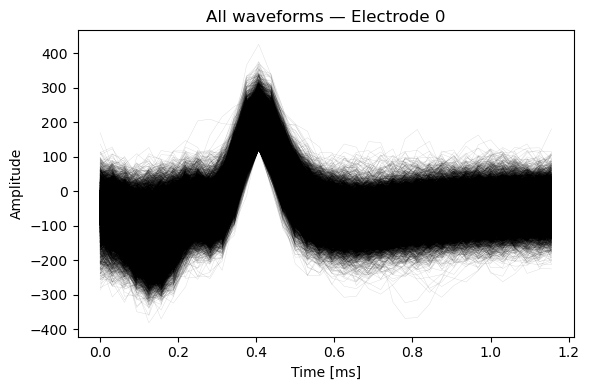

In [6]:
ELECTRODE = 0  # change as needed

wf = e.data['waveforms'].sel(electrodes=ELECTRODE)
wf_stacked = wf.stack(spike=('trials', 'spikes_idx'))
# Drop all-zero and all-NaN waveforms (padding)
valid = (wf_stacked != 0).any(dim='snippet_time') & (~wf_stacked.isnull()).any(dim='snippet_time')
wf_valid = wf_stacked.sel(spike=valid)  # shape: (snippet_time, spike)

print(f"Electrode {ELECTRODE}: {wf_valid.sizes['spike']} valid waveforms")
plt.figure(figsize=(6, 4))
plt.plot(wf_valid['snippet_time'] * 1_000, wf_valid.values, alpha=0.15, linewidth=0.3, color='k')
plt.xlabel('Time [ms]')
plt.ylabel('Amplitude')
plt.title(f'All waveforms — Electrode {ELECTRODE}')
plt.tight_layout()
plt.show()

### 3.2 Spike raster for one trial

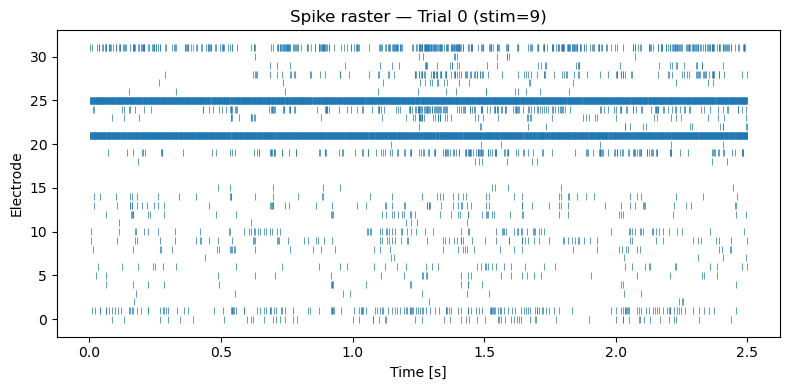

In [7]:
TRIAL = 0  # change as needed

st = e.data['spike_times'].sel(trials=TRIAL)
plt.figure(figsize=(8, 4))
for ch in range(e.nelectrodes):
    times = st.sel(electrodes=ch).values
    times = times[(times != 0) & ~np.isnan(times)]
    plt.vlines(times, ch - 0.4, ch + 0.4, linewidth=0.5)

plt.xlabel('Time [s]')
plt.ylabel('Electrode')
plt.title(f'Spike raster — Trial {TRIAL} (stim={int(e.data["stim_label"].sel(trials=TRIAL))})')
plt.tight_layout()
plt.show()

### 3.3 LFP trace for one electrode / trial

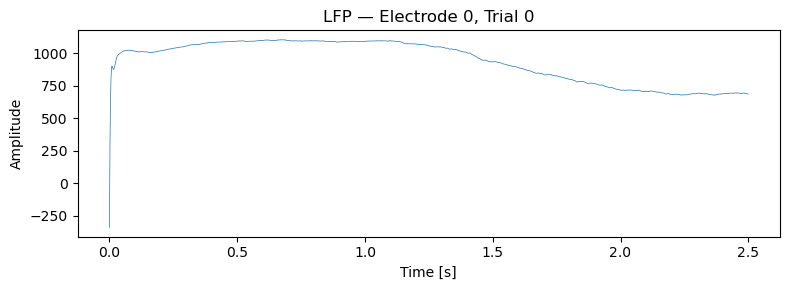

In [8]:
LFP_ELECTRODE = 0  # change as needed
LFP_TRIAL     = 0  # change as needed

lfp = e.data['lfp'].sel(electrodes=LFP_ELECTRODE, trials=LFP_TRIAL)
plt.figure(figsize=(8, 3))
plt.plot(lfp['lfp_time'], lfp.values, linewidth=0.5)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'LFP — Electrode {LFP_ELECTRODE}, Trial {LFP_TRIAL}')
plt.tight_layout()
plt.show()

---
## 4 — Spike-sorting results

### 4.1 Load from `.ssort` file (if available)

In [9]:
try:
    records = e.load_ssort()
    print(f"Loaded {len(records)} channel-trial records from .ssort")
    print(f"sorting_results stored: {e.sorting_results is not None}")
    print(f"cluster_labels shape:   {e.data['cluster_labels'].shape}")
    print()
    # Label distribution for first electrode / trial
    cl = e.data['cluster_labels'].sel(electrodes=0, trials=0)
    n = int(e.data['n_spikes'].sel(electrodes=0, trials=0))
    labels_valid = cl.values[:n]
    print(f"Electrode 0, Trial 0: {n} spikes, "
          f"unique labels: {np.unique(labels_valid[~np.isnan(labels_valid)]).astype(int)}")
except FileNotFoundError:
    print("No .ssort file found in the experiment directory.")
    print("You can use import_sorting_results() below to attach labels from memory.")

Loaded 7680 channel-trial records from .ssort
sorting_results stored: True
cluster_labels shape:   (32, 240, 2439)

Electrode 0, Trial 0: 61 spikes, unique labels: [0 1 2]


### 4.2 Import sorting results from memory (no file needed)

Replace the dummy random labels below with your actual sorting output.
The arrays must be in **trial-major, channel-minor** order
(`n_trials × n_electrodes` records).

In [ ]:
# ── Build label & index arrays (replace with your real data) ─────────
# Fixed master seed for reproducible demo output; use SeedSequence() (no
# arg) or secrets.randbits(128) for OS-entropy seeds in real work.
DEMO_SEED = 0xC7E5184D9B2F6A03
rng = Generator(PCG64DXSM(SeedSequence(DEMO_SEED)))
labels_per_record = []
spike_indices_per_record = []

for t in range(e.ntrials):
    for ch in range(e.nelectrodes):
        n = int(e.data['n_spikes'].sel(electrodes=ch, trials=t).values)
        # Dummy: random cluster labels 0, 1, or 2
        labels_per_record.append(rng.integers(0, 3, size=n))
        # Re-use existing spike times (convert back to sample indices)
        st = e.data['spike_times'].sel(electrodes=ch, trials=t).values[:n]
        spike_indices_per_record.append(
            (st * e.sample_rate_spike).astype(np.uint32)
        )
# ────────────────────────────────────────────────────────────────────

records = e.import_sorting_results(
    labels_per_record=labels_per_record,
    spike_indices_per_record=spike_indices_per_record,
)
print(f"Imported {len(records)} records")
print(f"cluster_labels shape: {e.data['cluster_labels'].shape}")
print(f"cluster_labels dtype: {e.data['cluster_labels'].dtype}")

### 4.3 Waveforms coloured by cluster label

/var/folders/44/d1_rx5gs6hx121g9yghqhvm80000gn/T/ipykernel_58606/3588757834.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(unique_labels), 1))


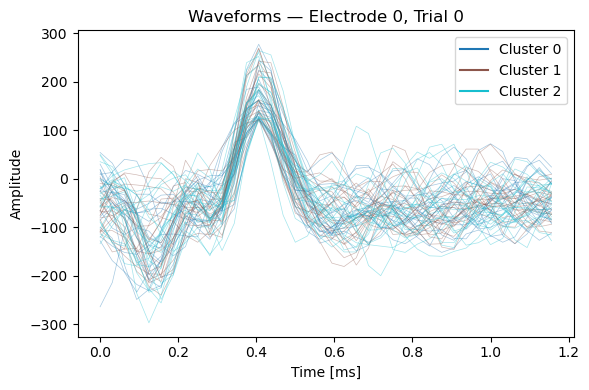

In [11]:
PLOT_ELECTRODE = 0
PLOT_TRIAL     = 0

try:
    wf = e.data['waveforms'].sel(electrodes=PLOT_ELECTRODE, trials=PLOT_TRIAL)
    cl = e.data['cluster_labels'].sel(electrodes=PLOT_ELECTRODE, trials=PLOT_TRIAL)
    n  = int(e.data['n_spikes'].sel(electrodes=PLOT_ELECTRODE, trials=PLOT_TRIAL))

    wf_valid = wf.isel(spikes_idx=slice(0, n))
    cl_valid = cl.isel(spikes_idx=slice(0, n)).values

    unique_labels = np.unique(cl_valid[~np.isnan(cl_valid)]).astype(int)
    cmap = plt.cm.get_cmap('tab10', max(len(unique_labels), 1))

    fig, ax = plt.subplots(figsize=(6, 4))
    for i, lbl in enumerate(unique_labels):
        mask = cl_valid == lbl
        for idx in np.where(mask)[0]:
            ax.plot(
                wf_valid['snippet_time'] * 1_000,
                wf_valid.isel(spikes_idx=idx),
                color=cmap(i), alpha=0.4, linewidth=0.5,
            )
        ax.plot([], [], color=cmap(i), label=f'Cluster {lbl}')

    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Waveforms — Electrode {PLOT_ELECTRODE}, Trial {PLOT_TRIAL}')
    ax.legend()
    plt.tight_layout()
    plt.show()
except KeyError:
    print("No cluster_labels available — run section 4.1 or 4.2 first.")

### 4.4 Save sorting results to `.ssort` file

In [12]:
# Uncomment to write the current sorting results to disk:
#
# saved_path = e.save_ssort(
#     labels_per_record=labels_per_record,
#     spike_indices_per_record=spike_indices_per_record,
# )
# print(f"Written to: {saved_path}")

print("save_ssort is commented out to avoid accidental overwrites.")
print("Uncomment the lines above when you want to persist results.")

save_ssort is commented out to avoid accidental overwrites.
Uncomment the lines above when you want to persist results.


---
## 5 — Zarr persistence (optional)

In [13]:
# Uncomment to save the experiment as a Zarr store:
#
e_zarr = Experiment()
e_zarr.load_from_dir(path=EXP_DIR, name=EXP_NAME, save_as='zarr')
zarr_path = os.path.join(EXP_DIR, f'{EXP_NAME}.zarr')
print(f"Zarr store at: {zarr_path}")

# Reload from Zarr (fast, no binary re-parsing)
ds_reloaded = load_from_zarr(zarr_path)
print(ds_reloaded)

print("Zarr save/reload is commented out. Uncomment when ready.")

Zarr store at: /Users/friedrichschwarz/test_data/natal/c5607a07 copy/c5607a07.zarr
<xarray.Dataset> Size: 3GB
Dimensions:       (electrodes: 32, trials: 240, lfp_time: 2500,
                   spikes_idx: 2439, snippet_time: 38)
Coordinates:
  * electrodes    (electrodes) int64 256B 0 1 2 3 4 5 6 ... 25 26 27 28 29 30 31
  * lfp_time      (lfp_time) float64 20kB 0.0 0.001 0.002 ... 2.497 2.498 2.499
  * snippet_time  (snippet_time) float64 304B 0.0 3.125e-05 ... 0.001156
  * spikes_idx    (spikes_idx) int64 20kB 0 1 2 3 4 ... 2434 2435 2436 2437 2438
  * trials        (trials) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
Data variables:
    lfp           (electrodes, trials, lfp_time) int16 38MB ...
    n_spikes      (electrodes, trials) int32 31kB ...
    spike_times   (electrodes, trials, spikes_idx) float32 75MB ...
    stim_label    (trials) int32 960B ...
    waveforms     (electrodes, trials, spikes_idx, snippet_time) float32 3GB ...
Attributes: (12/15)
    RecordName:    

/Users/friedrichschwarz/mambaforge/envs/da_analysis/lib/python3.12/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/Users/friedrichschwarz/mambaforge/envs/da_analysis/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
